# Character Recognition using an CNN

The ML network employed here is very similar to that used for the MLP assignment, the input image dimensions used in this model are 28x28 - the MNIST standard dimensions.

A key aspect of this notebook is illustrating how to set and get the weights for a given layer and how to extract the activation for a layer. These capabilities will be employed for generating per-layer golden reference data for verification of an implementation in another language, C++ for example.

This version of the model uses ReLu only as the activation function for the internal layers.

In [1]:

from __future__ import print_function
from keras.utils import to_categorical
import keras
from keras.datasets import mnist
from keras.models import Sequential, Model
from keras.layers import Input
from keras.layers import Dense, Dropout
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.optimizers import RMSprop
from matplotlib import pyplot
from matplotlib import pyplot as plt
import numpy as np

import sys
import os


In [2]:
keras.__version__

'3.13.2'

In [3]:
# some constants used in the program
# the number of rows and columns in an image
img_nrows = 28
img_ncols = 28
max_pixel = 255

# define the name of the directory for saving the various data structures
# to be used for HLS model development

path = 'hls/mnist_cnn_test1_data'


# training related constants

batch_size = 128
num_classes = 10
epochs = 20


In [4]:

# load train and test dataset
def load_dataset():
    (trainX, trainY), (testX, testY) = mnist.load_data()
    x_train_original = trainX.copy()
    trainX = trainX / 255.0
    testX = testX / 255.0

    # Reshape dataset to have a single channel
    trainX = trainX.reshape((trainX.shape[0], 28, 28, 1))
    testX = testX.reshape((testX.shape[0], 28, 28, 1))

    # One-hot encode target values
    trainY = to_categorical(trainY, num_classes)
    testY = to_categorical(testY, num_classes)

    return trainX, trainY, testX, testY, x_train_original

x_train, y_train, x_test, y_test, x_train_original = load_dataset()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
print(x_train.shape)
print(type(x_train))

(60000, 28, 28, 1)
<class 'numpy.ndarray'>


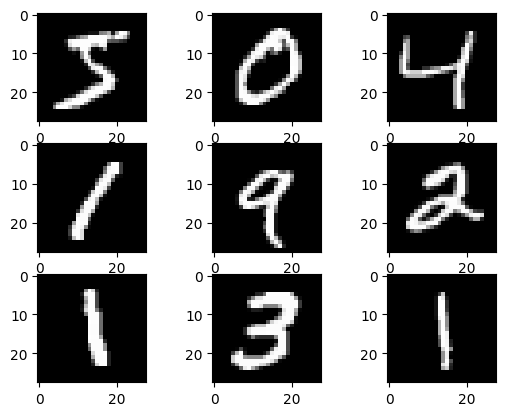

In [6]:
# plot first few images
for i in range(9):
	# define subplot
	pyplot.subplot(330 + 1 + i)
	# plot raw pixel data
	pyplot.imshow(x_train_original[i], cmap=pyplot.get_cmap('gray'))
# show the figure
pyplot.show()

In [7]:
keras.backend.clear_session()

input_layer = Input(shape=(28, 28, 1))
x = Conv2D(1, (3, 3), activation='relu', kernel_initializer='he_uniform', name='conv2d_0')(input_layer)
x = MaxPooling2D((2, 2), strides=(2,2), name='max_pool_0')(x)
x = Flatten()(x)
x = Dense(100, activation='relu', name='dense_0')(x)
x = Dropout(0.2)(x)
output_layer = Dense(num_classes, activation='softmax', name='dense_1')(x)

model = Model(inputs=input_layer, outputs=output_layer)

model.summary()

# Compile the model
model.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])

dummy_input = np.random.rand(1, 28, 28, 1)
model.predict(dummy_input)

# Train the model
history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

# Evaluate the model
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_0 (Conv2D)               │ (None, 26, 26, 1)      │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_0 (MaxPooling2D)       │ (None, 13, 13, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 169)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (Dense)                 │ (None, 100)            │        17,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,020 (70.39 KB)

 Trainable params: 18,020 (70.39 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.8464 - loss: 0.5229 - val_accuracy: 0.9365 - val_loss: 0.2187
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.9327 - loss: 0.2275 - val_accuracy: 0.9546 - val_loss: 0.1487
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.9461 - loss: 0.1804 - val_accuracy: 0.9607 - val_loss: 0.1247
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.9538 - loss: 0.1525 - val_accuracy: 0.9641 - val_loss: 0.1164
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.9572 - loss: 0.1413 - val_accuracy: 0.9655 - val_loss: 0.1092
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.9618 - loss: 0.1261 - val_accuracy: 0.9697 - val_loss: 0.0966
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.9635 - loss: 0.1195 - val_accuracy: 0.9694 - val_loss: 0.0937
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/st

Put a single image through the model

x0.shape =  (28, 28)
x0.shape =  (1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
prediction =  [[0 0 0 0 0 1 0 0 0 0]]


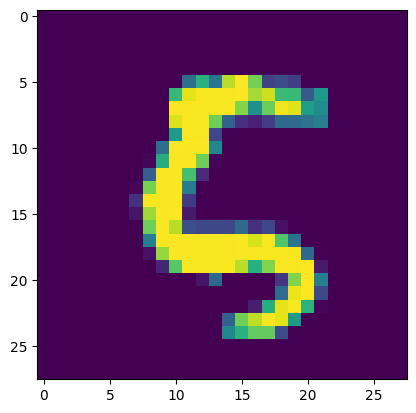

In [8]:
# select an arbitrary image from the mnist database
image_index = 2000
x0 = x_train_original[image_index]
print('x0.shape = ', x0.shape)
pyplot.imshow(x0)
x0 = x0.reshape((1, 28, 28, 1))
print('x0.shape = ', x0.shape)
x0 = np.divide(x0, 255.)
prediction = (model.predict(x0) > 0.5).astype("int32")
print('prediction = ', prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
(1, 26, 26, 1)
type(activation) =  <class 'numpy.ndarray'>
(26, 26)
(676,)


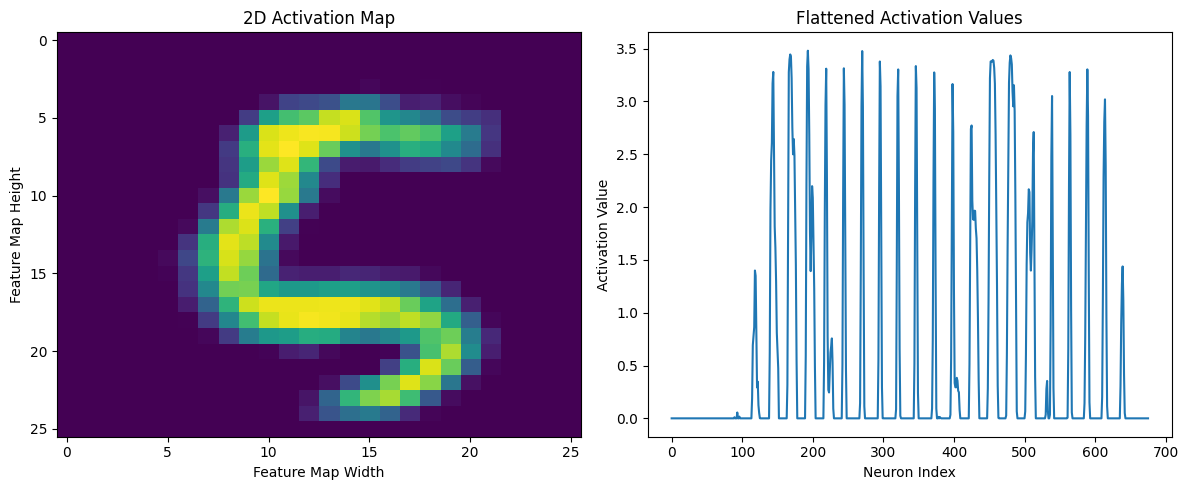

In [9]:

# Get activations from Conv2D layer
layer_name = 'conv2d_0'
conv_layer = model.get_layer(name=layer_name)

# Create an activation model
activation_model = Model(inputs=model.input, outputs=conv_layer.output)

# Extract activations
activation = activation_model.predict(x0)

print(activation.shape)
print('type(activation) = ', type(activation))

conv2d_0_out_ref = activation[0]  # Take the first image's activation output
conv2d_0_out_ref = conv2d_0_out_ref[:, :, 0]  # Extract the first channel

# Print shape of extracted activations
print(conv2d_0_out_ref.shape)

# Flatten the extracted activations
conv2d_0_out_ref_flat = conv2d_0_out_ref.reshape(1, -1)[0]

# Print flattened activation shape
print(conv2d_0_out_ref_flat.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(conv2d_0_out_ref, cmap='viridis', aspect='auto')
axes[0].set_title("2D Activation Map")
axes[0].set_xlabel("Feature Map Width")
axes[0].set_ylabel("Feature Map Height")

axes[1].plot(conv2d_0_out_ref_flat)
axes[1].set_title("Flattened Activation Values")
axes[1].set_xlabel("Neuron Index")
axes[1].set_ylabel("Activation Value")


plt.tight_layout()
plt.show()


In [10]:
# Get the weights for the first conv2D layer conv2d_0
model_weights = model.get_weights()

conv2d_0_w = model_weights[0]
conv2d_0_b = model_weights[1]

conv2d_0_w = conv2d_0_w[:,:,0,0]
print('conv2d_0_w.shape = ', conv2d_0_w.shape)
print('conv2d_0_w = ', conv2d_0_w)
print('conv2d_0_b = ', conv2d_0_b)

conv2d_0_w.shape =  (3, 3)
conv2d_0_w =  [[ 0.22048318  1.0340561   0.6739789 ]
 [ 0.88849485  0.62479633 -0.00920142]
 [ 0.00806027  0.09448986 -0.12959678]]
conv2d_0_b =  [-0.00286886]


/tmp/ipykernel_710/3223455877.py:2: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc


x0.shape =  (1, 28, 28, 1)
test_image.shape =  (28, 28)
(3, 3)
(26, 26)
(676,)


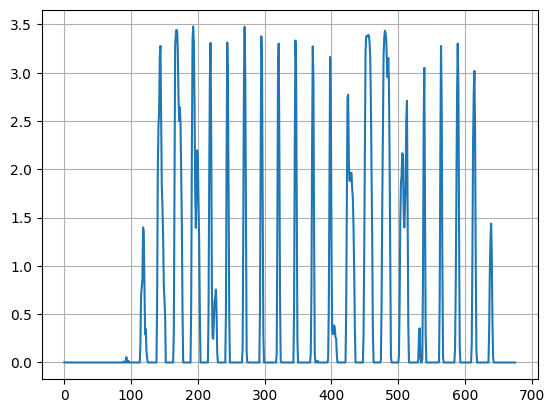

In [11]:
from scipy import signal
from scipy import misc
print('x0.shape = ', x0.shape)
test_image = x0[0,:,:,0]
print('test_image.shape = ', test_image.shape)
print(conv2d_0_w.shape)
conv2d_o = signal.correlate2d(test_image, conv2d_0_w, mode='valid')
print(conv2d_o.shape)
conv2d_o_flat = conv2d_o.reshape(1,conv2d_o.shape[0]*conv2d_o.shape[1])
conv2d_o_flat = conv2d_o_flat[0]
conv2d_o_flat = conv2d_o_flat + conv2d_0_b
print(conv2d_o_flat.shape)

# ReLu
conv2d_o_relu_flat = np.maximum(conv2d_o_flat, 0)
pyplot.plot(conv2d_o_relu_flat)
pyplot.grid()

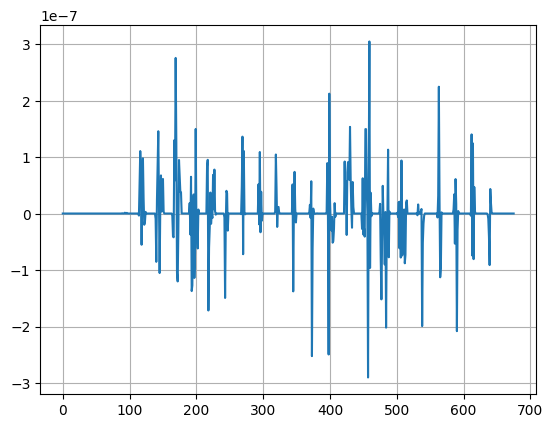

In [12]:
conv2d_0_out_diff = conv2d_0_out_ref_flat - conv2d_o_relu_flat
pyplot.plot(conv2d_0_out_diff)
pyplot.grid()

In [13]:
def max_pool(x, u, v):
    M, N = x.shape
    K = u
    L = v

    MK = M // K
    NL = N // L

    a = x[:MK*K, :NL*L]
    b = x[:MK*K, :NL*L].reshape(MK, K, NL, L).max(axis=(1, 3))

    return(b)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
(13, 13, 1)


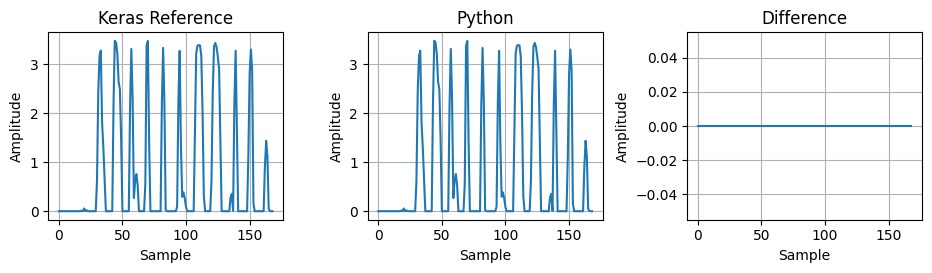

In [14]:
# Get activations from MaxPooling2D layer
layer_name = 'max_pool_0'
max_pool_layer = model.get_layer(name=layer_name)

# Create an activation model
activation_model = Model(inputs=model.input, outputs=max_pool_layer.output)

# Extract activations
max_pool_0_out = activation_model.predict(x0)  # x0 is the input image

# Extract and flatten activations (matching keract behavior)
max_pool_0_out_ref = max_pool_0_out[0].flatten()

# Print shape of extracted activations
print(max_pool_0_out[0].shape)

# Compute max_pool using native Python function
maxpool_o = max_pool(conv2d_0_out_ref, 2, 2)  # Assuming you have a function `max_pool`
maxpool_o_flat = maxpool_o.flatten()

# Plot results
plot_nrows = 1
plot_ncols = 3
fig, axes = plt.subplots(nrows=plot_nrows, ncols=plot_ncols, figsize=(10, 3))
ax0, ax1, ax2 = axes.flatten()
fig.tight_layout(pad=3.0)

x_vals = np.arange(len(max_pool_0_out_ref))

# Plot Keras reference activation
ax0.plot(x_vals, max_pool_0_out_ref, label='Reference')
ax0.set(xlabel='Sample', ylabel='Amplitude', title='Keras Reference')
ax0.grid()

# Plot native Python max-pool results
ax1.plot(x_vals, maxpool_o_flat, label='Native Python')
ax1.set(xlabel='Sample', ylabel='Amplitude', title='Python')
ax1.grid()

# Plot difference between Keras and native Python max-pooling
max_pool_0_out_diff = max_pool_0_out_ref - maxpool_o_flat
ax2.plot(x_vals, max_pool_0_out_diff)
ax2.set(xlabel='Sample', ylabel='Amplitude', title='Difference')
ax2.grid()

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
type(dense_0_out) =  <class 'numpy.ndarray'>
dense_0_out.shape =  (100,)


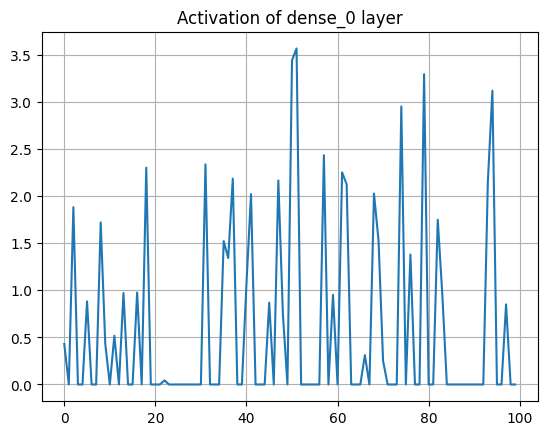

In [15]:
# Get activations from the first Dense layer
layer_name = 'dense_0'
dense_layer = model.get_layer(name=layer_name)

# Create an activation model to extract outputs from the selected dense layer
activation_model = Model(inputs=model.input, outputs=dense_layer.output)

# Extract activations (output of dense layer)
dense_0_out = activation_model.predict(x0)  # x0 is the input image

# Extract activations and plot
dense_0_out = dense_0_out[0]  # Get the output for the batch (only one image in the batch)

# Print the type and shape of the activations
print('type(dense_0_out) = ', type(dense_0_out))
print('dense_0_out.shape = ', dense_0_out.shape)

# Plot the activations (first layer output)
pyplot.plot(dense_0_out)
pyplot.grid()
pyplot.title('Activation of dense_0 layer')
pyplot.show()


In [16]:
# Get the weights for the first dense layer dense_0
model_weights = model.get_weights()
# print(type(model_weights))
# print(len(model_weights))
# print(model_weights)
w0 = model_weights[2]
b0 = model_weights[3]
w1 = model_weights[4]
b1 = model_weights[5]
# print(w0.shape)
# print(b0.shape)
# print(w1.shape)
# print(b1.shape)

Using basic python code compute the output of the first layer in the model

model.add(Dense(25, activation='sigmoid', input_shape=(784,),name='dense_0'))

In [17]:
def sigmoid(x):
    return(1./(1. + np.exp(-x)))

def softmax(x):
    return(np.exp(x)/sum(np.exp(x)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


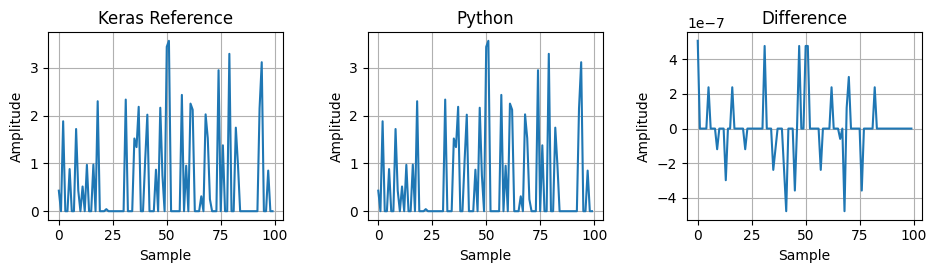

In [18]:
# Get the input to the dense layer (flattened output)
# This is the output of the Flatten layer, which becomes the input to 'dense_0'
layer_name = 'flatten'
flatten_layer = model.get_layer(name=layer_name)

# Create a model that outputs the activation of the flatten layer
activation_model = Model(inputs=model.input, outputs=flatten_layer.output)

# Get activations (output from the Flatten layer)
dense_0_in = activation_model.predict(x0)  # x0 is the input image
dense_0_in = dense_0_in[0]  # Only one sample in the batch, extract first sample

# Assume weights (w0) and biases (b0) are available
# (These should be extracted from the Dense layer if needed)
w0 = model.get_layer('dense_0').get_weights()[0]
b0 = model.get_layer('dense_0').get_weights()[1]

# Perform matrix-vector product for Dense layer input
o_0 = np.dot(dense_0_in, w0)  # Matrix-vector multiplication
dense_0_linear_out = o_0 + b0  # Add bias term
dense_0_outp = np.maximum(dense_0_linear_out, 0)  # Apply ReLU activation

# Get the output of the first dense layer in the model
dense_0_out = model.get_layer('dense_0').output
dense_0_out_model = Model(inputs=model.input, outputs=dense_0_out)
dense_0_out = dense_0_out_model.predict(x0)  # Forward pass through Dense layer

# Extract the output and plot it
dense_0_out_ref = dense_0_out[0]

# Visualization
x_vals = np.arange(len(dense_0_out_ref))

plot_nrows = 1
plot_ncols = 3

fig, axes = pyplot.subplots(nrows=plot_nrows, ncols=plot_ncols, figsize=(10,3))
ax0, ax1, ax2 = axes.flatten()
fig.tight_layout(pad=3.0)

# Plot reference activation (Keras)
ax0.plot(x_vals, dense_0_out_ref, label='Reference')
ax0.set(xlabel='Sample', ylabel='Amplitude', title='Keras Reference')
ax0.grid()

# Plot custom computed activation (Native Python)
ax1.plot(x_vals, dense_0_outp, label='Native Python')
ax1.set(xlabel='Sample', ylabel='Amplitude', title='Python')
ax1.grid()

# Plot the difference between the two activations
dense_0_out_diff = dense_0_out_ref - dense_0_outp
ax2.plot(x_vals, dense_0_out_diff)
ax2.set(xlabel='Sample', ylabel='Amplitude', title='Difference')
ax2.grid()

pyplot.show()


In [19]:
print(dense_0_linear_out.shape)
print(dense_0_linear_out)

(100,)
[ 4.2989919e-01 -1.4896460e+00  1.8822693e+00 -4.2207856e+00
 -1.1043944e+00  8.8198507e-01 -2.9324296e-01 -6.9087887e-01
  1.7203697e+00  4.3275210e-01 -3.1705639e+00  5.1719481e-01
 -9.7992163e+00  9.7030151e-01 -6.5832343e+00 -5.7731986e+00
  9.7637504e-01 -5.5668324e-01  2.3016944e+00 -3.5498037e+00
 -2.5141141e+00 -7.9735732e-01  4.3113343e-02 -2.1583567e+00
 -7.2585630e+00 -3.8279700e-01 -2.5694556e+00 -4.1368217e+00
 -2.3582687e+00 -4.5993513e-01 -4.4176097e+00  2.3365505e+00
 -2.9454577e+00 -3.4327443e+00 -4.9855384e-01  1.5217766e+00
  1.3417456e+00  2.1853211e+00 -3.3709967e-01 -2.1334579e+00
  1.0679095e+00  2.0205963e+00 -2.2582273e+00 -4.1265802e+00
 -2.6650748e+00  8.6883104e-01 -3.7018313e+00  2.1656973e+00
  7.4805897e-01 -2.6497871e-01  3.4407201e+00  3.5667746e+00
 -1.0971541e+00 -6.2127995e-01 -3.9394224e+00 -3.4621179e+00
 -8.2484770e+00  2.4342916e+00 -2.4652441e+00  9.5212084e-01
 -1.9326429e+00  2.2521622e+00  2.1248429e+00 -2.6625185e+00
 -2.2317320e-01 -

In [20]:
print(dense_0_in.shape)
print(dense_0_in)
print(w0.shape)
print(w0[:])

(169,)
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.01018773 0.         0.05513929 0.         0.01638024 0.
 0.         0.         0.         0.         0.         0.
 0.6212577  2.4386387  3.1695697  3.2781386  1.815768   1.2911993
 0.631291   0.         0.         0.         0.         0.
 0.         2.1993742  3.4790668  3.443895   3.2203553  2.6437166
 2.4864483  1.4508502  0.         0.         0.         0.
 0.         0.         2.1280947  3.3125422  2.3002586  0.26902184
 0.62051064 0.7564377  0.5270646  0.         0.         0.
 0.         0.         0.55722487 3.3770437  3.4756494  1.4034642
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         2.1837971  3.3336365  2.2021987
 0.02393498 0.         0.         0.         0.         0.
 0.         0.         0.         0.09441899 2.2451248  3.273536
 1.3259

fig, axes = plt.subplots(nrows=2, ncols=2)
ax0, ax1, ax2, ax3 = axes.flatten()

colors = ['red', 'tan', 'lime']
ax0.hist(x, n_bins, normed=1, histtype='bar', color=colors, label=colors)
ax0.legend(prop={'size': 10})
ax0.set_title('bars with legend')

ax1.hist(x, n_bins, normed=1, histtype='bar', stacked=True)
ax1.set_title('stacked bar')

ax2.hist(x, n_bins, histtype='step', stacked=True, fill=False)
ax2.set_title('stack step (unfilled)')

#Make a multiple-histogram of data-sets with different length.
x_multi = [np.random.randn(n) for n in [10000, 5000, 2000]]
ax3.hist(x_multi, n_bins, histtype='bar')
ax3.set_title('different sample sizes')

fig.tight_layout()
plt.show()

#another example
import matplotlib.pyplot as plt
import numpy as np

f = plt.figure(figsize=(10,3))
ax = f.add_subplot(121)
ax2 = f.add_subplot(122)
x = np.linspace(0,4,1000)
ax.plot(x, np.sin(x))
ax2.plot(x, np.cos(x), 'r:')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


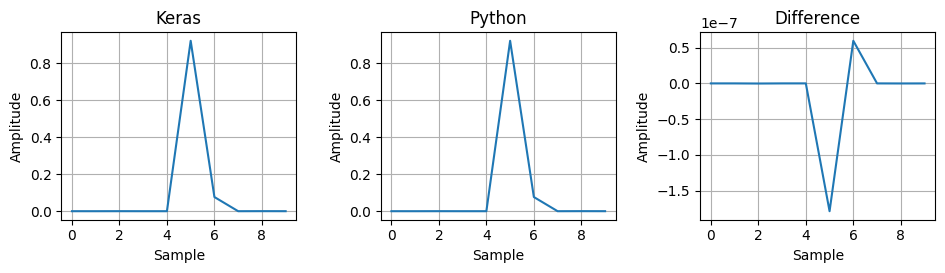

Max difference between Keras and custom output: 5.960464477539063e-08


In [21]:
# Define the activation function for softmax
def softmax(x):
    exp_x = np.exp(x - np.max(x))  # Subtract max for numerical stability
    return exp_x / exp_x.sum(axis=-1, keepdims=True)

# Compute the output of the 2nd dense layer (dense_1) using matrix-vector product
dense_1_linear_out = np.dot(dense_0_out_ref, w1)  # Matrix-vector product for Dense layer
dense_1_linear_out = dense_1_linear_out + b1  # Add bias
dense_1_outp = softmax(dense_1_linear_out)  # Apply Softmax activation

# Get the output of the 2nd dense layer from the model (using the model directly)
dense_1_out_model = Model(inputs=model.input, outputs=model.get_layer('dense_1').output)
dense_1_out = dense_1_out_model.predict(x0)  # Forward pass to get the output of 'dense_1'

# Extract the reference output from Keras
dense_1_out_ref = dense_1_out[0]  # For single sample

# Compute the difference between the custom and Keras outputs
dense_1_out_diff = dense_1_out_ref - dense_1_outp
dense_1_out_diff_max = np.max(dense_1_out_diff)

# Plot the comparison between Keras output and custom output
xvals = np.arange(len(dense_1_out_diff))

plot_nrows = 1
plot_ncols = 3
fig, axes = pyplot.subplots(nrows=plot_nrows, ncols=plot_ncols, figsize=(10,3))
fig.tight_layout(pad=3.0)
ax0, ax1, ax2 = axes.flatten()

# Plot Keras output (Reference)
ax0.plot(xvals, dense_1_out_ref)
ax0.grid()
ax0.set(xlabel='Sample', ylabel='Amplitude', title='Keras')

# Plot custom output (Python)
ax1.plot(xvals, dense_1_outp)
ax1.grid()
ax1.set(xlabel='Sample', ylabel='Amplitude', title='Python')

# Plot the difference between Keras and custom output
ax2.plot(xvals, dense_1_out_diff)
ax2.grid()
ax2.set(xlabel='Sample', ylabel='Amplitude', title='Difference')

pyplot.show()

# Optional: Print the max difference
print(f'Max difference between Keras and custom output: {dense_1_out_diff_max}')


In [22]:
print(dense_1_linear_out)

[-13.004986  -26.39539   -11.528053  -15.705098  -13.649163   -2.9651814
  -5.452691  -18.82431   -11.033932  -12.117727 ]


In [23]:
print(w1.shape)

(100, 10)


# Save all of the data structures that will be required for development and verification of the HLS model

In [24]:
np.set_printoptions(threshold=np.inf)
def to_c_array(name, arr, c_type="float"):
    body = np.array2string(
    arr,
    separator=', ',
    threshold=arr.size,
    floatmode='fixed',
    formatter={'float_kind': lambda x: f"{x:.10f}"})
    body = body.replace('[', '{').replace(']', '}')
    if arr.ndim == 1:
        size = arr.shape[0]
        return f"static const {c_type} {name}[{size}] = {body};\n"
    elif arr.ndim == 2:
        rows, cols = arr.shape
        return f"static const {c_type} {name}[{rows}][{cols}] = {body};\n"
    else:
        raise ValueError("Only 1D or 2D arrays supported")

In [25]:
# save the model parameters, the weights and bias values

model_params_fname = 'params.dat'

# first create the directory for storing the model weights, inputs, and golden output
# reference (the groundtruth data)

if not os.path.exists(path):
    try:
        os.makedirs(path)
    except OSError:
        print ("Creation of the directory %s failed" % path)
    else:
        print ("Successfully created the directory %s " % path)

# THIS IS LINUX PATH, YOU NEED TO CHANGE IT IF YOU WANT TO USE THIS ON WINDOWS
#model_param_filename = path + '/' + model_params_fname

print("Files will be saved to:", os.path.abspath(path))
# os.path.join works on both Windows and Linux
model_param_filename = os.path.join(path, model_params_fname)
#print('\n' + 'writing model parameters to ' + path + '/' + model_params_fname)
print('\n' + 'writing model parameters to ' +  model_param_filename)

# Save the weights for the first convolution layer.
# This includes the 9 weights associated with the 3x3 convolution and the one bias value

with open(model_param_filename, "w") as f:
    #np.savetxt(f, np.reshape(np.transpose(conv2d_0_w), conv2d_0_w.shape[0]*conv2d_0_w.shape[1]), newline='\n')
    np.savetxt(f, np.reshape(conv2d_0_w, conv2d_0_w.shape[0]*conv2d_0_w.shape[1]), newline='\n')
    np.savetxt(f, conv2d_0_b)
    #f.write('start of dense_0' + '\n')
    np.savetxt(f, np.reshape(np.transpose(w0), w0.shape[0]*w0.shape[1]), newline='\n')
    np.savetxt(f, b0)
    np.savetxt(f, np.reshape(np.transpose(w1), w1.shape[0]*w1.shape[1]), newline='\n')
    np.savetxt(f, b1)

Successfully created the directory hls/mnist_cnn_test1_data 
Files will be saved to: /content/hls/mnist_cnn_test1_data

writing model parameters to hls/mnist_cnn_test1_data/params.dat


In [26]:
# filename for storing the input image
input_image_fname = 'image.dat'

# filename for storing the ground-truth corresponding to the network input(s)
groundtruth_fname = 'groundtruth.dat'

# filename for saving the per-layer trace data
trace_data_fname = 'trace.dat'


print('\n' + 'writing trace data to ' + path + '/' + trace_data_fname )
print('\n' + 'writing input image to ' + path + '/' + input_image_fname )
print('\n' + 'writing groundtruth to ' + path + '/' + groundtruth_fname )

with open(path + '/' + input_image_fname , "w") as f:
    # save the input image (flattened)
    np.savetxt(f, np.reshape(test_image, test_image.shape[0]*test_image.shape[1]),
               newline='\n')

groundtruth_tmp = np.atleast_1d(prediction)

with open(path + '/' + groundtruth_fname , "w") as f:
    np.savetxt(f, groundtruth_tmp, fmt='%d', newline='\n')

with open(path + '/' + trace_data_fname , "w") as f:
    np.savetxt(f, conv2d_o_flat)
    np.savetxt(f, conv2d_o_relu_flat)
    np.savetxt(f, maxpool_o_flat)
    #f.write('start of dense_0' + '\n')
    np.savetxt(f, dense_0_linear_out.transpose()) # don't need transpose
    np.savetxt(f, dense_0_outp)
    np.savetxt(f, dense_1_linear_out)
#    np.savetxt(f, dense_1_linear_out.transpose


writing trace data to hls/mnist_cnn_test1_data/trace.dat

writing input image to hls/mnist_cnn_test1_data/image.dat

writing groundtruth to hls/mnist_cnn_test1_data/groundtruth.dat


In [27]:
conv2d0_w = np.reshape(conv2d_0_w, conv2d_0_w.shape[0]*conv2d_0_w.shape[1])
conv2d0_b = conv2d_0_b
arrays = {
    "conv2d0_w": conv2d0_w.astype(np.float32),
    "conv2d0_b": conv2d0_b.astype(np.float32),
}

for name, arr in arrays.items():
    file_path = path + '/' + name + ".h"

    with open(file_path, "w") as f:
        guard = f"{name.upper()}_H"

        f.write(f"#ifndef {guard}\n")
        f.write(f"#define {guard}\n\n")
        f.write(to_c_array(name, arr, "float"))
        f.write("\n#endif\n")

    print(f"Saved {file_path}")

Saved hls/mnist_cnn_test1_data/conv2d0_w.h
Saved hls/mnist_cnn_test1_data/conv2d0_b.h


In [28]:
print(conv2d_0_w)
print(np.reshape(conv2d_0_w, conv2d_0_w.shape[0]*conv2d_0_w.shape[1]))
print(b0)

[[ 0.22048318  1.0340561   0.6739789 ]
 [ 0.88849485  0.62479633 -0.00920142]
 [ 0.00806027  0.09448986 -0.12959678]]
[ 0.22048318  1.0340561   0.6739789   0.88849485  0.62479633 -0.00920142
  0.00806027  0.09448986 -0.12959678]
[-2.01597530e-03 -2.06671253e-01 -1.40796512e-01 -1.62289932e-01
  2.80646719e-02 -1.80200487e-01 -3.34715754e-01  2.91185733e-03
 -2.11790174e-01 -2.04759747e-01 -5.88499084e-02  4.88796718e-02
 -1.72230080e-02  1.08191885e-01  2.30163541e-02 -5.58848456e-02
 -2.06645653e-01 -1.83635771e-01 -3.58334959e-01 -7.97248557e-02
 -7.77473394e-03 -1.48433298e-01 -1.04659803e-01 -1.47944009e-02
 -1.08910851e-01  1.01105802e-01  2.75434032e-02 -4.27029207e-02
 -3.57415080e-01 -9.09813792e-02  3.37858731e-03 -2.56650848e-04
  1.85333856e-03 -6.57394454e-02 -3.22710186e-01  1.24315418e-01
 -1.06699606e-02  7.91309867e-03  9.91842747e-02 -2.23742500e-01
  7.14556053e-02 -2.68812805e-01 -4.86337170e-02  2.94623543e-02
 -2.07524840e-02 -1.33836612e-01 -1.05109140e-01 -3.0039

In [29]:
print(dense_0_linear_out)

[ 4.2989919e-01 -1.4896460e+00  1.8822693e+00 -4.2207856e+00
 -1.1043944e+00  8.8198507e-01 -2.9324296e-01 -6.9087887e-01
  1.7203697e+00  4.3275210e-01 -3.1705639e+00  5.1719481e-01
 -9.7992163e+00  9.7030151e-01 -6.5832343e+00 -5.7731986e+00
  9.7637504e-01 -5.5668324e-01  2.3016944e+00 -3.5498037e+00
 -2.5141141e+00 -7.9735732e-01  4.3113343e-02 -2.1583567e+00
 -7.2585630e+00 -3.8279700e-01 -2.5694556e+00 -4.1368217e+00
 -2.3582687e+00 -4.5993513e-01 -4.4176097e+00  2.3365505e+00
 -2.9454577e+00 -3.4327443e+00 -4.9855384e-01  1.5217766e+00
  1.3417456e+00  2.1853211e+00 -3.3709967e-01 -2.1334579e+00
  1.0679095e+00  2.0205963e+00 -2.2582273e+00 -4.1265802e+00
 -2.6650748e+00  8.6883104e-01 -3.7018313e+00  2.1656973e+00
  7.4805897e-01 -2.6497871e-01  3.4407201e+00  3.5667746e+00
 -1.0971541e+00 -6.2127995e-01 -3.9394224e+00 -3.4621179e+00
 -8.2484770e+00  2.4342916e+00 -2.4652441e+00  9.5212084e-01
 -1.9326429e+00  2.2521622e+00  2.1248429e+00 -2.6625185e+00
 -2.2317320e-01 -2.55364

In [30]:
print(dense_1_out_ref)
np.sum(dense_1_out_ref)

[4.0255065e-05 6.1580338e-11 1.7629654e-04 2.7050612e-06 2.1137726e-05
 9.2268234e-01 7.6690376e-02 1.1954141e-07 2.8896047e-04 9.7757933e-05]


np.float32(1.0)